# inverse medium scattering problem
This is an example for the `regpy.solvers.nonlinear.irgnm.IrgnmCG` solver for the example of __medium scattering__

In medium scattering we try to determine a perturbation $f$ the refractive index $1+f$ of a medium from measurements of far ﬁeld patterns $u_{\infty}$ of scattered time-harmonic acoustic waves $u - u_{inc}$ in this medium. The total field $u$ satisfies 

$$
 \Delta u + k^2 (1+f) u = 0 \qquad \text{in } \mathbb{R}^2
$$

The __Iteratively Regularized Gauss-Newton Method (IRGNM)__ minimizes in each iteration 
$$
  f_{n+1}  = f_n + \argmin_{h} \Vert F(f_{n}) + F'[f_n] h - u_{\infty}^{obs}\Vert^{2} + \alpha_{n}  \Vert f_{n} + h - f_0\Vert^{2}
$$
where $F$ is a Frechet-differentiable operator, using `regpy.solvers.linear.tikhonov.TikhonovCG`.
$\alpha_n$ is a decreasing geometric sequence of regularization parameters.

In [1]:
from examples.medium_scattering.mediumscattering import MediumScatteringFixed
from regpy.operators import CoordinateProjection
from regpy.hilbert import L2, HmDomain
from regpy.solvers import RegularizationSetting
from regpy.solvers.nonlinear.irgnm import IrgnmCG
import regpy.stoprules as rules
import regpy.util as util

import numpy as np
import logging

import matplotlib.pyplot as plt
import matplotlib.colorbar as cbar


logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-20s :: %(message)s'
)

In [2]:
# building the forwrd  operator
radius = 1
scattering = MediumScatteringFixed(
    gridshape=(64, 64),
    radius=radius,
    wave_number=1,
    inc_directions=util.linspace_circle(16),
    farfield_directions=util.linspace_circle(16),
)

projection = CoordinateProjection(
    scattering.domain,
    scattering.support
)
embedding = projection.adjoint

op = scattering * embedding



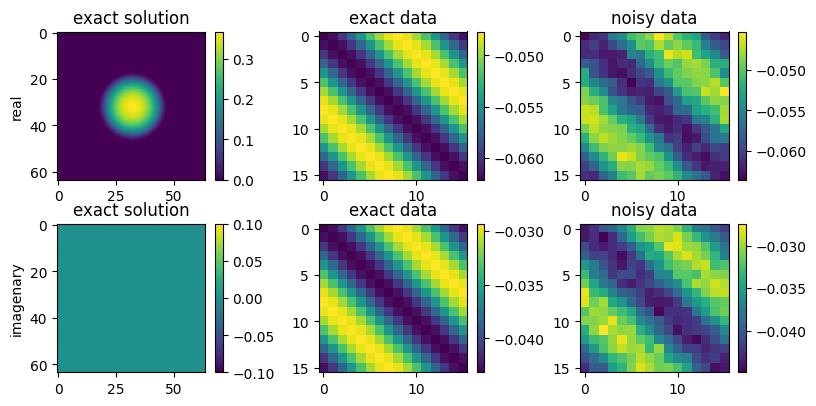

In [3]:
#creating data
contrast = scattering.domain.zeros()
r = np.linalg.norm(scattering.domain.coords, axis=0)
contrast[r < radius] = np.exp(-1/(radius - r[r < radius]**2))



exact_solution = projection(contrast)
exact_data = op(exact_solution)
# create and add noise
noise = 0.001 * op.codomain.randn()
data = exact_data + noise
init = op.domain.zeros()


#plotting 
fig,axs = plt.subplots(2,3,figsize=(8,4))
fig.tight_layout()
ax = axs[0,0]
im = ax.imshow(contrast.real)
fig.colorbar(im,ax=ax)
ax.set_ylabel('real')
ax.set_title('exact solution')
ax = axs[0,1]
im = ax.imshow(exact_data.real)
fig.colorbar(im,ax=ax)
ax.set_title('exact data')
ax = axs[0,2]
im = ax.imshow(data.real)
fig.colorbar(im,ax=ax)
ax.set_title('noisy data')
ax = axs[1,0]
ax.set_ylabel('imagenary')
im = ax.imshow(contrast.imag)
fig.colorbar(im,ax=ax)
ax.set_title('exact solution')
ax = axs[1,1]
im = ax.imshow(exact_data.imag)
fig.colorbar(im,ax=ax)
ax.set_title('exact data')
ax = axs[1,2]
im = ax.imshow(data.imag)
fig.colorbar(im,ax=ax)
ax.set_title('noisy data')
plt.show();

In [4]:
#create setting
myh_domain = HmDomain(scattering.domain,scattering.support,dtype=complex,index=2)
setting = RegularizationSetting(
    op=op,
    # Define Sobolev norm on support via embedding
    penalty = myh_domain, 
    data_fid=L2
)


In [5]:
#set up solver
solver = IrgnmCG(
    setting, data,
    regpar=0.0001, regpar_step=0.8,
    init=init,
    cg_pars=dict(
        tol=1e-8,
        reltolx=1e-8,
        reltoly=1e-8
    )
)
#set up stopping creiteria
stoprule = (
    rules.CountIterations(100) +
    rules.Discrepancy(
        setting.h_codomain.norm, data,
        noiselevel=setting.h_codomain.norm(noise),
        tau=1.1
    )
)
reco, reco_data = solver.run(stoprule)



2024-04-16 19:12:25,960 INFO CountIterations      :: iteration = 0 / 100
2024-04-16 19:12:25,960 INFO Discrepancy          :: relative discrepancy = 48.16, tolerance = 1.10
2024-04-16 19:12:26,145 INFO TikhonovCG           :: it.5 err/Tol X:6.4e-08/1.0e-08 Y:7.9e-09/1.0e-08 
2024-04-16 19:12:26,146 INFO TikhonovCG           :: Solver converged after 5 iteration.
2024-04-16 19:12:26,206 INFO CountIterations      :: iteration = 1 / 100
2024-04-16 19:12:26,207 INFO Discrepancy          :: relative discrepancy = 10.40, tolerance = 1.10
2024-04-16 19:12:27,096 INFO TikhonovCG           :: it.6 err/Tol X:3.8e-07/1.0e-08 Y:6.0e-08/1.0e-08 res.red: 9.3e-09/1.0e-08
2024-04-16 19:12:27,098 INFO TikhonovCG           :: Solver converged after 6 iteration.
2024-04-16 19:12:27,176 INFO CountIterations      :: iteration = 2 / 100
2024-04-16 19:12:27,177 INFO Discrepancy          :: relative discrepancy = 1.67, tolerance = 1.10
2024-04-16 19:12:28,565 INFO TikhonovCG           :: it.8 err/Tol X:1.6e-0

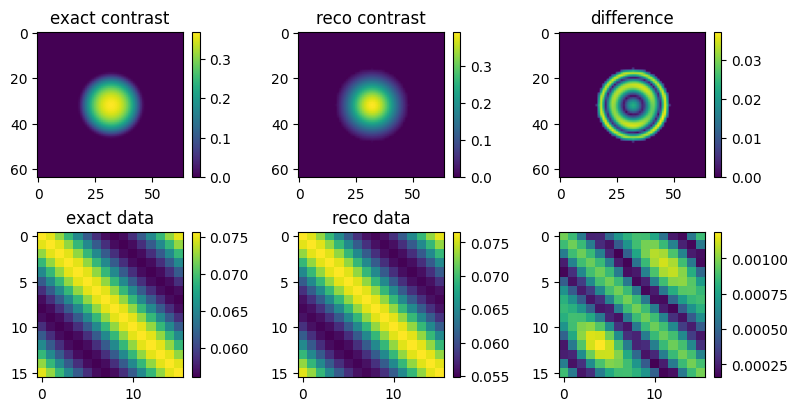

In [6]:
fig, axes = plt.subplots(ncols=3, nrows=2, constrained_layout=True,figsize=(8,4))
bars = np.vectorize(lambda ax: cbar.make_axes(ax)[0], otypes=[object])(axes)

axes[0, 0].set_title('exact contrast')
axes[1, 0].set_title('exact data')
axes[0, 1].set_title('reco contrast')
axes[1, 1].set_title('reco data')
axes[0, 2].set_title('difference')

def show(i, j, x):
    im = axes[i, j].imshow(x)
    bars[i, j].clear()
    fig.colorbar(im, cax=bars[i, j])

show(0, 0, np.abs(contrast))
show(1, 0, np.abs(exact_data))
solution = embedding(reco)
show(0, 1, np.abs(solution))
show(1, 1, np.abs(reco_data))
show(0, 2, np.abs(solution - contrast))
show(1, 2, np.abs(exact_data - reco_data))
plt.show();
